# Flagging Data in `GSData` Objects

In this tutorial, we'll follow up on the `data_loading_and_writing` tutorial, and take some real EDGES data and perform some flagging. 

You can of course write your own flagging routines -- every experiment will have their own customized routines. However, this is also a good time to introduce `edges-analysis`, which includes several fairly generic flagging routines which you might find useful right off the bat.

In [1]:
from edges import filters
from edges.cal import dicke
from edges.cal.apply import approximate_temperature
from edges.averaging import average_over_times

/data7/smurray/edges/workshop-notes/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pygsdata import GSData, plots

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from astropy import units as un
from pathlib import Path

In [3]:
results = Path("results")

## Read Data

Just as in the previous tutorial, we will use some real EDGES data here. 
In this case, we're going to read all four of the files you downloaded, but we'll down-select the frequencies and times up-front so that we're dealing with less data.

We'll select on just outside the 50-100 MHz range, which is the final range we're interested in.
We'll also select on LSTs for which the galaxy is down, to get less bright foregrounds. 

In [4]:
gsh5_files = sorted(Path("data").glob("*.gsh5"))

In [5]:
data = []
for fl in gsh5_files:
    data.append(
            GSData.from_file(
            fl, 
            selectors={
                "freq_selector": {
                    "freq_range": (45 * un.MHz, 105 * un.MHz)
                },
                "lst_selector": {
                    "lst_range": (0, 12)
                }
            }
        )
    )

Let's print out the shape of each of our files:

In [6]:
for d in data:
    print(d.name, d.data.shape)

2016-259 (3, 1, 1131, 9831)
2016-261 (3, 1, 1132, 9831)
2016-263 (3, 1, 1136, 9831)
2016-265 (3, 1, 1130, 9831)


## Basic Filters: Sun and Moon

The first thing we might want to do is to flag out data taken during the day, or with the moon overhead. 

In [7]:
data = [filters.sun_filter(d, elevation_range = (-90, 0)) for d in data]

In [8]:
data = [filters.moon_filter(d, elevation_range = (-90, 20)) for d in data]

The first thing to note is that this does not _remove_ integrations from the data: 

In [9]:
for d in data:
    print(d.name, d.data.shape)

2016-259 (3, 1, 1131, 9831)
2016-261 (3, 1, 1132, 9831)
2016-263 (3, 1, 1136, 9831)
2016-265 (3, 1, 1130, 9831)


However, it does add _flags_ to the data:

In [10]:
data[0].flags

{'sun_filter': GSFlag(flags=array([ True,  True,  True, ...,  True,  True,  True], shape=(1131,)), axes=('time',), history=!!python/tuple []
 , filename=None),
 'moon_filter': GSFlag(flags=array([False, False, False, ..., False, False, False], shape=(1131,)), axes=('time',), history=!!python/tuple []
 , filename=None)}

This is the first time we've seen something in the `flags` dictionary, so let's take a bit closer look. Each key is the name of the filter that was applied. The value of each entry is a `GSFlag` object. The important thing about this object is that it doesn't necessarily need to have the same full shape as the data. In this instance, both of our filters have the `axes = ('time',)` attribute, which means they flag out entire integrations (all frequencies at a particular time). This means we are able to store just a 1D array, and `GSData` knows how to broadcast these flags over the data array.

Separating each filter's flags like this means you can determine which filters are most stringent on your data. However, it is also convenient to be able to combine all the flags you've determined so far. This can be done with the `.complete_flags` attribute:

In [11]:
data[0].complete_flags.shape

(3, 1, 1131, 9831)

This is a full-shaped boolean array of all the flags from all filters (ORed).

To use only _some_ of the filters:

In [12]:
data[0].get_cumulative_flags(which_flags=("sun_filter",)).shape

(3, 1, 1131, 9831)

Another important thing to consider is that for some operations you may want to only consider "nsamples" as being the indicator of the weight of a datum, but if a datum is flagged it should receive zero weight. Flagging a sample does _not_ automatically set its weight to zero:

In [13]:
np.any(data[0].complete_flags)

np.True_

In [14]:
np.any(data[0].nsamples==0)

np.False_

However, you can use the combined information from nsamples and flags by using the `flagged_nsamples` attribute:

In [15]:
np.sum(data[0].flagged_nsamples==0)

np.int64(27251532)

In [16]:
np.sum(data[0].complete_flags)

np.int64(27251532)

## Simple Calibration

This tutorial is mostly about flagging, but some of our filters will rely on the data being roughly calibrated, and so let's perform Dicke calibration, and a very rough receiver calibration:

In [17]:
cal_data = [dicke.dicke_calibration(d) for d in data]

In [18]:
cal_data = [approximate_temperature(d, tload=300, tns=1000) for d in cal_data]

Now that we have some "calibrated" data, let's make a waterfall plot to see if everything is as expected:

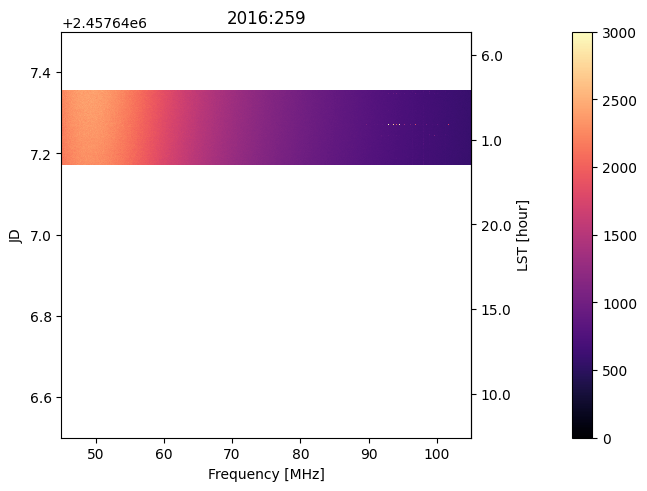

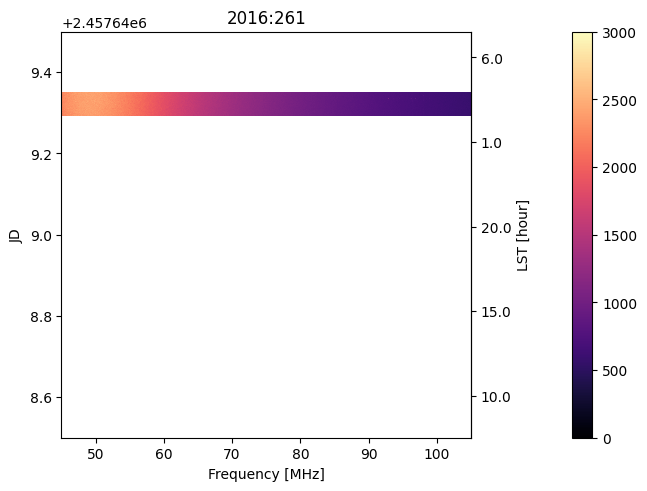

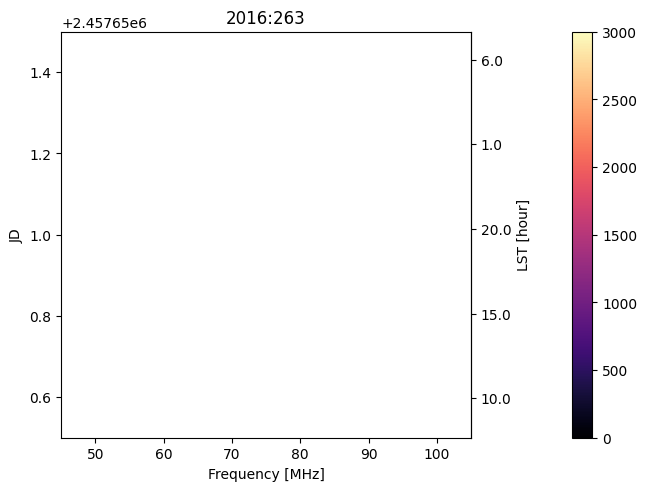

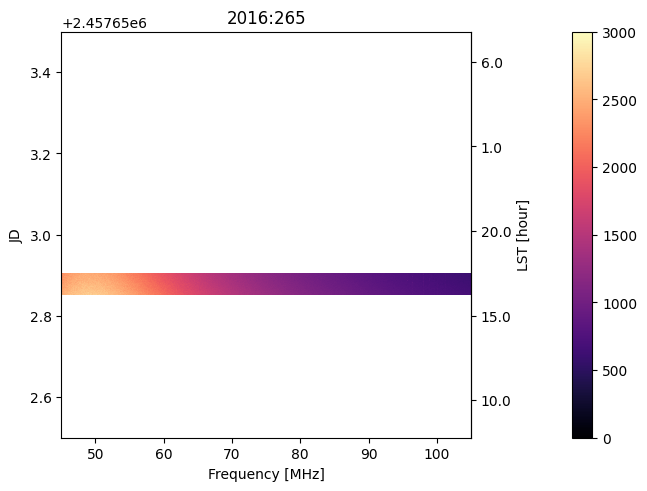

In [19]:
for d in cal_data:
    plots.plot_waterfall(d, vmin=0, vmax=3000)

Here, the `plot_waterfall` function is automatically omitting flagged data, so we're only seeing the "good" data. Notice that the third day has no good data left that satisfies the criteria of being galaxy-down, sun-down and moon-down. 

## Average over times

I would like to show you the RFI flagging algorithm in `edges-analysis`. It works on 2D waterfalls like this, but the effects are easier to visualize on a single spectrum (and it is faster in this case as well), so for the sake of this tutorial, let's average all times on each night together (except the third night, since it doesn't have any data left...):

In [20]:
single_spec_data = []
for d in cal_data:
    if np.all(d.complete_flags):
        continue
    
    single_spec_data.append(
        average_over_times(
            d, 
            use_resids=False, 
        )
    )
    

Let's plot each spectrum:

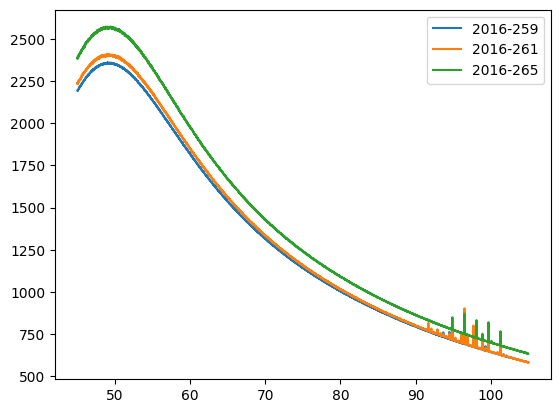

In [21]:
for d in single_spec_data:
    plt.plot(d.freqs, d.data.flatten(), label=d.name)
plt.legend()

Notice here that we had to `.flatten()` the data (because even though it has a single load, single pol and single "time", it is still a 4D array!).

## RFI Flagging

`edges-analysis` comes with some RFI filters that you can apply right away. These filters are generally based on fitting models to the data, subtracting them, getting an estimate of the noise, and finding outliers.

In [22]:
from edges.filters import rfi_iterative_filter
from edges.filters.xrfi import LinearModeler
from edges import modeling as mdl

In [23]:
single_spec_data = [
    rfi_iterative_filter(
        d,
        data_modeler = LinearModeler(            
            model = mdl.Fourier(n_terms=37, period=1.5, transform=mdl.ZerotooneTransform(
                range=(
                    d.freqs.min().to_value("MHz"), 
                    d.freqs.max().to_value("MHz"),
                )
            ))
        ),
        std_modeler=LinearModeler(            
            model = mdl.Fourier(n_terms=5, period=1.5, transform=mdl.ZerotooneTransform(
                range=(
                    d.freqs.min().to_value("MHz"), 
                    d.freqs.max().to_value("MHz"),
                )
            ))
        ),
        max_iter=100,
        threshold_setter = lambda x: 2.5,
        watershed = {
            1.0: 4,
            10.0: 8,
            100.0: 16
        },
    ) for d in single_spec_data
]

This looks a bit more complicated. You can check exactly what this RFI algorithm is doing by reading the docs, or reading the upcoming paper.

The `rfi_iterative_filter` is a very flexible function, and we're using essentially just its defaults here. The defaults 
are to do a high-pass fourier-filter of the data, and then fit the absolute residuals with a lower-order Fourier model to estimate the standard deviation, which is then used to identify outliers. This is done in an iterative loop, where on each iteration, the fits are performed only on the data that was left unflagged from the previous iteration. This keeps iterating until the flags remain constant 
between iterations.

Let's plot the spectra again, to see if we caught the RFI (at least visually):

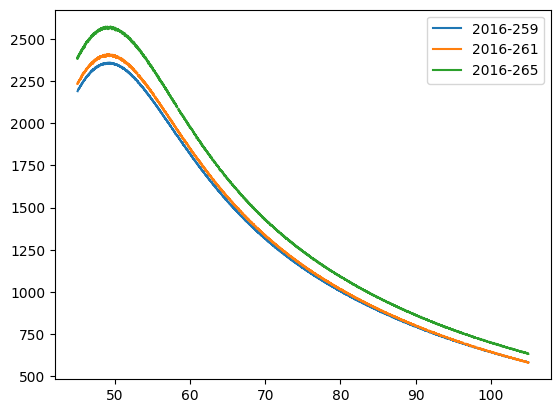

In [24]:
for d in single_spec_data:
    plt.plot(
        d.freqs, 
        np.where(d.complete_flags, np.nan, d.data).flatten(), 
        label=d.name
    )
plt.legend()

## Write out our files for the next tutorial to use

Let's write out our files so we can read them in the next tutorial:

In [26]:
for d in single_spec_data:
    d.write_gsh5(results / f"{d.name}.singlespec.gsh5")